In [3]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [4]:
#load the dataset

data = pd.read_csv('/content/Customer-Churn-Dataset.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning

In [5]:
print('\n Info about the dataset:\n')
print(data.info())


 Info about the dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBillin

In [6]:
#check for missing values
missing_values = data.isnull().sum()
missing_values

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
# Remove duplicate records
data = data.drop_duplicates()

In [8]:
# Number of duplicate rows
duplicate_count = data.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [9]:
#check for inconsistencies
cat_cols = data.select_dtypes(include = ['object']).columns
for col in cat_cols:
  print(f"\nColumn: {col}")
  print(data[col].unique())


Column: customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

Column: gender
['Female' 'Male']

Column: Partner
['Yes' 'No']

Column: Dependents
['No' 'Yes']

Column: PhoneService
['No' 'Yes']

Column: MultipleLines
['No phone service' 'No' 'Yes']

Column: InternetService
['DSL' 'Fiber optic' 'No']

Column: OnlineSecurity
['No' 'Yes' 'No internet service']

Column: OnlineBackup
['Yes' 'No' 'No internet service']

Column: DeviceProtection
['No' 'Yes' 'No internet service']

Column: TechSupport
['No' 'Yes' 'No internet service']

Column: StreamingTV
['No' 'Yes' 'No internet service']

Column: StreamingMovies
['No' 'Yes' 'No internet service']

Column: Contract
['Month-to-month' 'One year' 'Two year']

Column: PaperlessBilling
['Yes' 'No']

Column: PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Column: TotalCharges
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Column: Churn


 #### Observation
- No such inconsistencies in data type of columns found.

In [10]:
# Numerical columns
numerical_columns = data.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns
categorical_columns = data.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [11]:
# Summary Statistics for Categorical columns
data[categorical_columns].describe()

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [12]:
# Symmary Statistics for Numerical columns
data[numerical_columns].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
# Convert TotalCharges to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors = 'coerce')
# Handling missing values
# Since TotalCharges column hav tenure 0 so replace with 0
data['TotalCharges'] = data['TotalCharges'].fillna(0)

In [14]:
# Check for incorrect datatypes (if any)
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [15]:
# Cleaned Dataset in CSV format
data.to_csv('Cleaned_Churn_Dataset.csv')

## Exploratory Data Analysis (EDA)

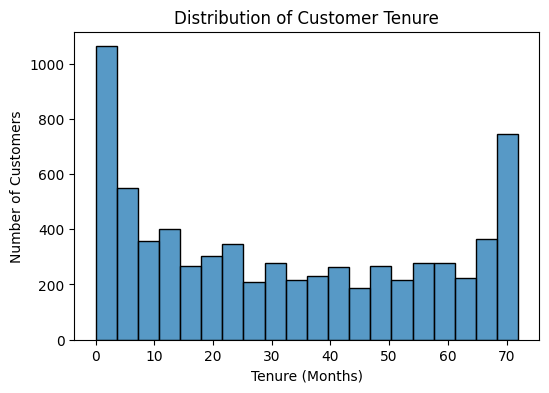

In [16]:
# ------------------------
# Univariate Analysis
# ------------------------

#Tenure Distribution (Histogram)
plt.figure(figsize=(6,4))
sns.histplot(data['tenure'], bins=20, kde= False)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

#### Observation
- Most customers have shorter tenure, indicating higher churn risk during the early
subscription period.

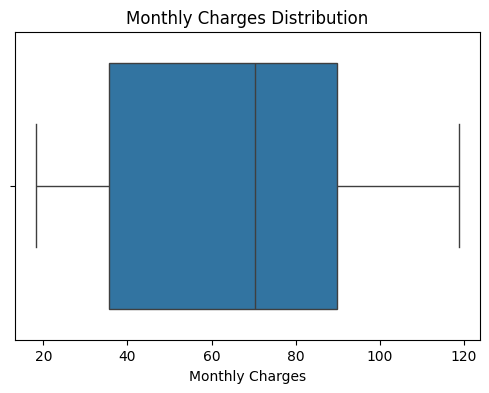

In [17]:
# Monthly Charges Distribution (Boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(x=data['MonthlyCharges'])
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.show()

#### Observation
- Monthly charges show a wide range of values, indicating variability in customer
subscription plans. However, no significant outliers are observed, suggesting that monthly
charges are fairly well distributed across customers without extreme values

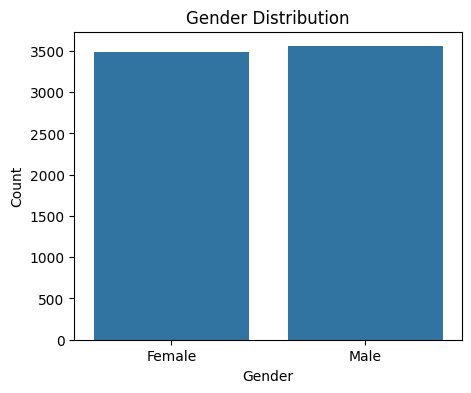

In [18]:
# Gender Distribution (Bar chart)
plt.figure(figsize=(5,4))
sns.countplot(x='gender', data= data)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

#### Observation
- The dataset shows a nearly balanced distribution of male and female customers indication
no significant bias in the customer base.

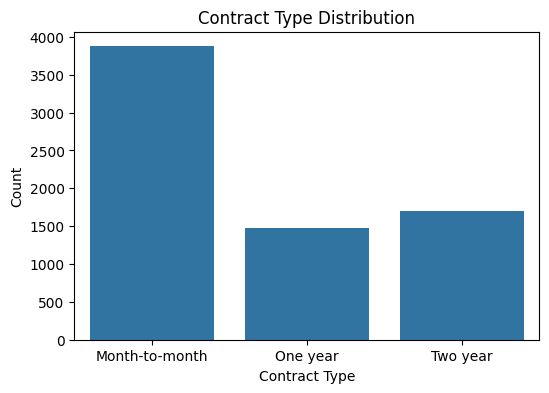

In [19]:
# Contract Type Distribution (Bar chart)
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', data=data)
plt.title("Contract Type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()

#### Observation
- Month-to-month contracts are the most common among customers. This indicates a
preference for short-term commitments, which may have implications for customer
retention.


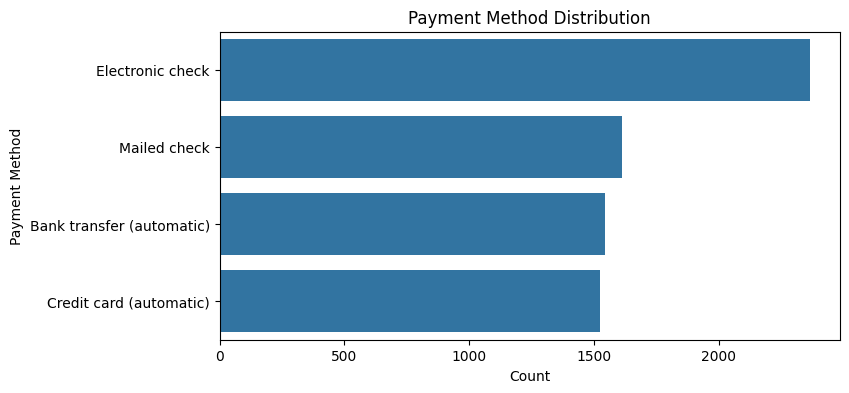

In [20]:
# Payment Method Distribution (Bar chart)
plt.figure(figsize=(8,4))
sns.countplot(y='PaymentMethod', data=data)
plt.title("Payment Method Distribution")
plt.xlabel("Count")
plt.ylabel("Payment Method")
plt.show()

#### Observation
- Electronic check is the most frequently used payment method. This highlights customer
preference toward digital payment modes.

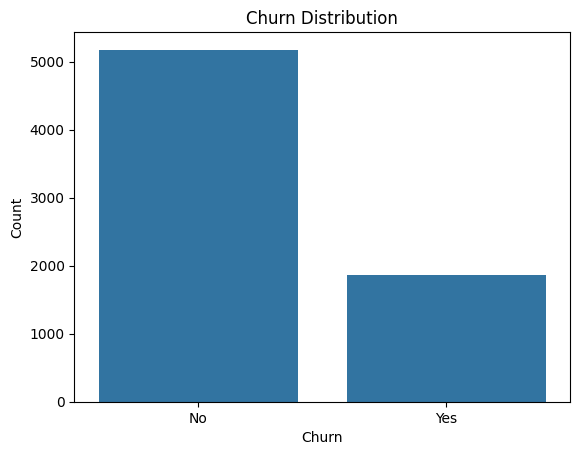

In [21]:
# -----------------------------
# Bivariate Analysis
# -----------------------------

# Churn Distribution (Bar chart)
sns.countplot(x='Churn', data=data)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

#### Observation
- The target variable shows a significant class imbalance, indicating that model evaluation should prioritize Recall over Accuracy to effectively capture the minority churn group.

In [22]:
# Contract type vs Churn (crosstab + bar chart)

#crosstab
pd.crosstab(data['Contract'],data['Churn'], normalize= 'index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


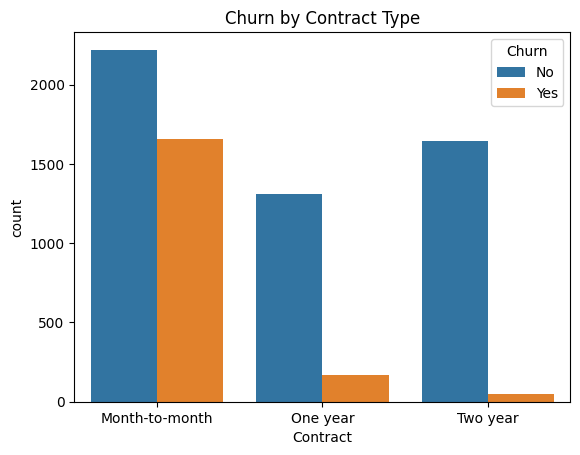

In [23]:
sns.countplot(x = 'Contract', hue = 'Churn', data = data)
plt.title("Churn by Contract Type")
plt.show()

#### Observation
- Higher churn is observed among customers with month-to-month contracts compared to
long-term contracts.

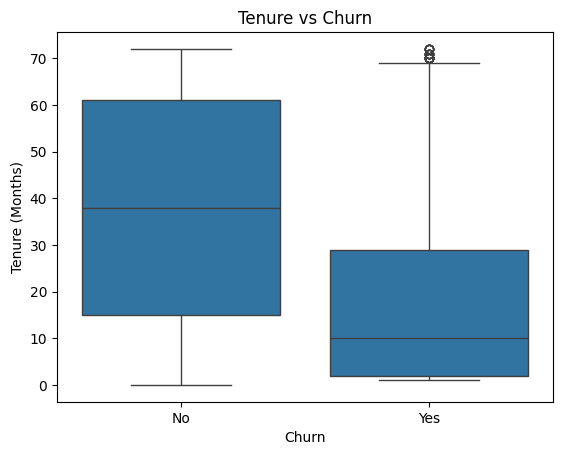

In [24]:
# tenure vs Churn (Group Comparison)
sns.boxplot(x='Churn', y='tenure', data=data)
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

#### Observation
- Customers whochurngenerally have lower tenure than retained customers. This indicates
that customers are more likely to churn during the early stages of their subscription.

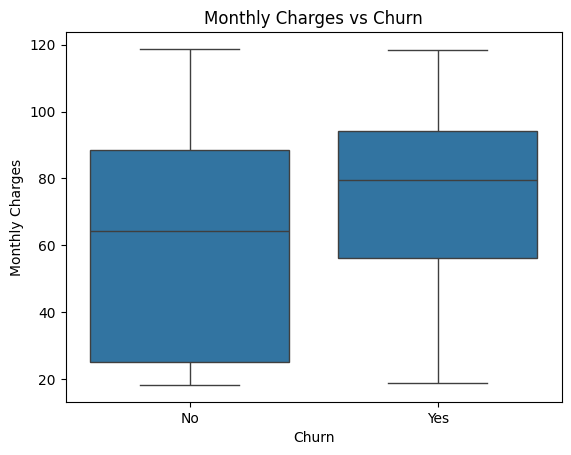

In [25]:
# MonthlyCharges vs Churn (Group comparison)
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


#### Observation
- Customers with higher monthly charges tend to churn more frequently suggesting that
pricing may play a role in customer dissatisfaction

In [26]:
# PaymentMethod vs Churn (crosstab + bar chart)
pd.crosstab(data['PaymentMethod'], data['Churn'], normalize='index')


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


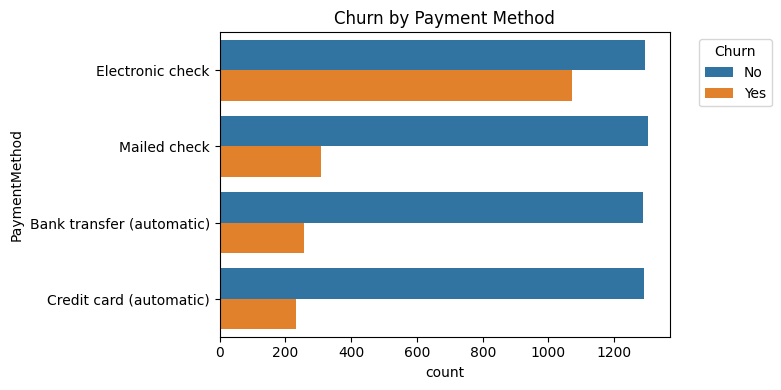

In [27]:
plt.figure(figsize = (8,4))
sns.countplot(y='PaymentMethod', hue='Churn', data=data)
plt.title("Churn by Payment Method")
plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Observation
- Electronic check users show higher churn rates than customers using automatic payment
methods, indicating that payment convenience may influence retention

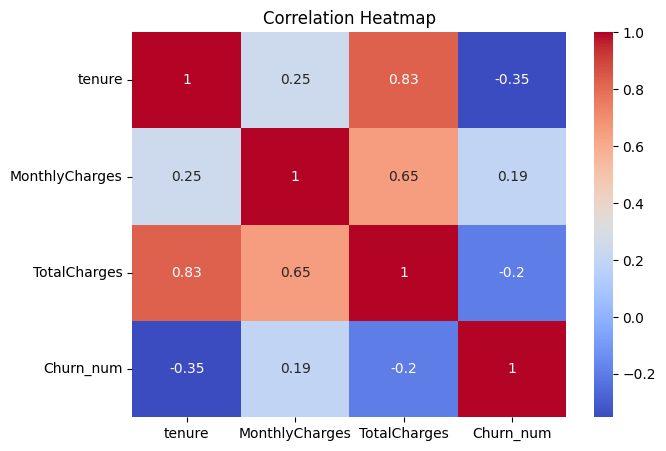

In [28]:
# Correlation Heatmap
df_corr = data.copy()
df_corr['Churn_num'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(7,5))
sns.heatmap(df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Observation
- Churn showsastrong negative correlation with tenure, indicating that longer-tenured
customers are less likely to churn. Monthly charges show a positive correlation with churn,
suggesting that higher costs may increase churn likelihood

## Feature Engineering

In [29]:
# target distribution
data['Churn'].value_counts(normalize = True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [30]:
# Creating Meaningful Features

# # 1. AverageMonthlySpend: Calculated as TotalCharges divided by tenure
# Using (tenure + 1) to prevent division by zero for new customers
data['AverageMonthlySpend'] = data['TotalCharges'] / (data['tenure'] + 0.1)

# 2. ContractType: Creating a simplified contract category
# Grouping Month-to-month as 'Short-term' and others as 'Long-term'
data['ContractType'] = data['Contract'].apply(lambda x: 'Short-term' if x == 'Month-to-month' else 'Long-term')

# 3. Customer Tenure Category: Binning tenure into logical groups
def get_tenure_group(tenure):
    if tenure <= 12: return '0-1 Year'
    elif tenure <= 24: return '1-2 Years'
    elif tenure <= 48: return '2-4 Years'
    else: return '4+ Years'

data['TenureCategory'] = data['tenure'].apply(get_tenure_group)

In [31]:
# Remove Irrelevant columns
df_clean = data.drop(columns=['customerID'])

In [32]:
df_clean.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [33]:
# Encoding Categoricals variables
le = LabelEncoder()

# Binary Encoding (for columns with 2 unique values)
binary_cols = [col for col in df_clean.columns if df_clean[col].nunique() == 2]
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# One-Hot Encoding (for multi-category columns)
df_final = pd.get_dummies(df_clean)

print(f"Feature Engineering Complete. Dataset shape: {df_final.shape}")

Feature Engineering Complete. Dataset shape: (7043, 47)


## Applying Logistic Regression Model as Baseline ML Model

In [34]:
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (Scaling is critical for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and Evaluate Baseline
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train_scaled, y_train)

def get_performance_metrics(model, X, y_true):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_prob)
    }

baseline_metrics = get_performance_metrics(baseline_model, X_test_scaled, y_test)
print("\nBaseline Model (Logistic Regression) Results:")
print(pd.Series(baseline_metrics))


Baseline Model (Logistic Regression) Results:
Accuracy     0.811923
Precision    0.673077
Recall       0.563003
F1-Score     0.613139
AUC-ROC      0.859882
dtype: float64


In [35]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

comparison_results = [{'Model': 'Logistic Regression (Baseline)', **baseline_metrics}]

for name, model in models.items():
    model.fit(X_train, y_train) # Tree models handle non-scaled data well
    metrics = get_performance_metrics(model, X_test, y_test)
    metrics['Model'] = name
    comparison_results.append(metrics)

# Display Comparison Table
comparison_df = pd.DataFrame(comparison_results).set_index('Model')
print("\nModel Comparison Table:")
print(comparison_df)


Model Comparison Table:
                                Accuracy  Precision    Recall  F1-Score  \
Model                                                                     
Logistic Regression (Baseline)  0.811923   0.673077  0.563003  0.613139   
Decision Tree                   0.720369   0.472868  0.490617  0.481579   
Random Forest                   0.789922   0.637993  0.477212  0.546012   
Gradient Boosting               0.809794   0.677966  0.536193  0.598802   

                                 AUC-ROC  
Model                                     
Logistic Regression (Baseline)  0.859882  
Decision Tree                   0.647439  
Random Forest                   0.840714  
Gradient Boosting               0.860020  


#### Observation
- Gradient Boosting and Logistic Regression emerged as the top-performing models, achieving the highest AUC-ROC (~0.84) and F1-Scores, indicating a superior ability to balance precision and recall for churn detection.

In [36]:
# Tuning the Random Forest model for better performance
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print(f"\nBest Hyperparameters found: {rf_grid.best_params_}")


Best Hyperparameters found: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


## Final Model Evaluation

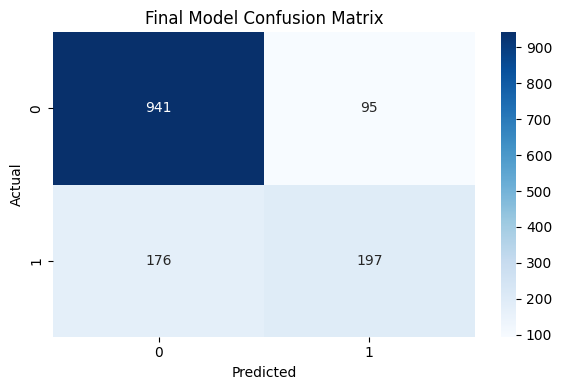

In [37]:
y_pred_final = best_rf.predict(X_test)
y_prob_final = best_rf.predict_proba(X_test)[:, 1]

# 1. Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues')
plt.title('Final Model Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


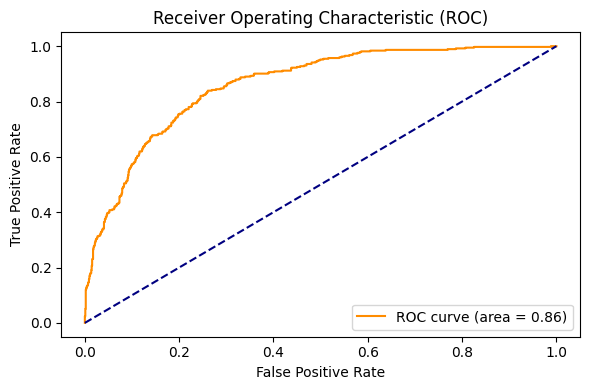

In [38]:
# 2. AUC-ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc_score(y_test, y_prob_final):.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

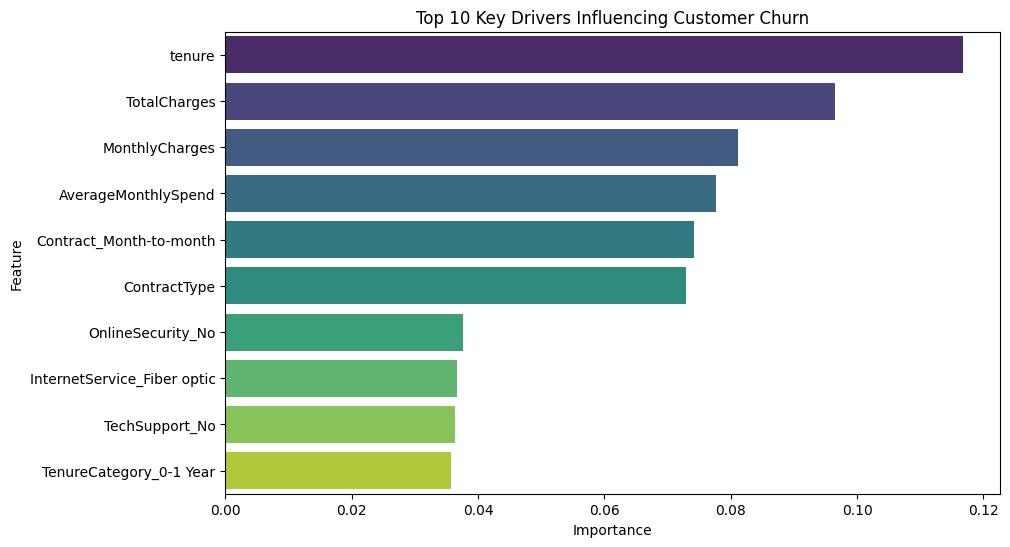

In [39]:
# 3. Feature Importance Visualization
importances = best_rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Key Drivers Influencing Customer Churn')
plt.show()

In [40]:
import pickle

import pickle

# 1. Save the Label Encoder
with open('label_encoders.pkl', 'wb') as le_file:
    pickle.dump(le, le_file)

# 2. Save the Scaler
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

# 3. Save the Model
with open('baseline_model.pkl', 'wb') as model_file:
    pickle.dump(baseline_model, model_file)

print("All 3 components (Encoders, Scaler, Model) are ready for Streamlit!")

All 3 components (Encoders, Scaler, Model) are ready for Streamlit!
